# Tamaño del clon mayor y secuencias únicas

Este código genera un gráfico para evaluar la relación entre el **tamaño del clon mayor** y la **proporción de secuencias únicas (singletons)** en los escenarios simulados (A–E).

El eje `x` representa el tamaño del clon mayor en escala logarítmica y el eje `y` la proporción de secuencias únicas. Cada punto corresponde a un repertorio y su tamaño representa el **número de clones** (`n_clones`). Las líneas conectan los puntos correspondientes a cada escenario.

## Funciones usadas

* `options()` → define el tamaño y resolución del gráfico.
* `ggplot()` → crea el gráfico.
* `aes()` → define las variables de los ejes, color y tamaño.
* `filter()` → filtra las filas según una condición.
* `geom_line()` → agrega las líneas.
* `geom_point()` → agrega los puntos.
* `geom_text()` → agrega las etiquetas de los escenarios.
* `scale_x_log10()` → establece el eje `x` en escala logarítmica.
* `scale_size()` → controla el tamaño de los puntos según `n_clones`.
* `scale_color_manual()` → asigna los colores de los escenarios.
* `coord_cartesian()` → permite mostrar elementos fuera del área del gráfico.
* `labs()` → define los títulos de los ejes y la leyenda.
* `theme_light()` → establece el tema base.
* `theme()` → personaliza textos, márgenes, cuadrícula y leyenda.

El gráfico permite comparar visualmente la **expansión clonal** y la proporción de secuencias únicas entre los diferentes escenarios.


In [1]:
library(tidyverse)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.2.1     v readr     2.1.5
v forcats   1.0.1     v stringr   1.6.0
v ggplot2   4.0.0     v tibble    3.3.0
v lubridate 1.9.5     v tidyr     1.3.1
v purrr     1.2.0     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::filter() masks stats::filter()
x dplyr::lag()    masks stats::lag()
i Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
d <- read_tsv(
  "/Users/catg/Desktop/SOFIAC/Gitsofia/tesisbioinf-sofia/results/clonal_table/clonal_metrics.tsv",
  show_col_types = FALSE
) |>
  mutate(completo = n_secuencias >= 0.99 * profundidad)

d %>% head()

escenario,profundidad,n_secuencias,n_clones,singletons,proporcion_singletons,clon_mayor,completo
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
A,100,100,100,100,1.0000000,1,TRUE
A,200,200,197,194,0.9847716,2,TRUE
A,400,400,394,388,0.9847716,2,TRUE
A,800,800,770,747,0.9701299,5,TRUE
A,1600,1600,1522,1472,0.9671485,6,TRUE
A,3200,3200,2983,2840,0.9520617,15,TRUE


In [4]:
fin <- d |>
  filter(completo) |>
  slice_max(profundidad, by = escenario) |>
  left_join(summarise(d, trunco = any(!completo), .by = escenario), by = "escenario") |>
  mutate(etiqueta = paste0(
    escenario, ".", formatC(n_clones, big.mark = ".", decimal.mark = ",", format = "d"),
    " clones"
  ))

In [5]:
d[] <- lapply(d, function(x) {
  if (is.character(x)) iconv(x, from = "UTF-8", to = "UTF-8") else x
})

fin[] <- lapply(fin, function(x) {
  if (is.character(x)) iconv(x, from = "UTF-8", to = "UTF-8") else x
})

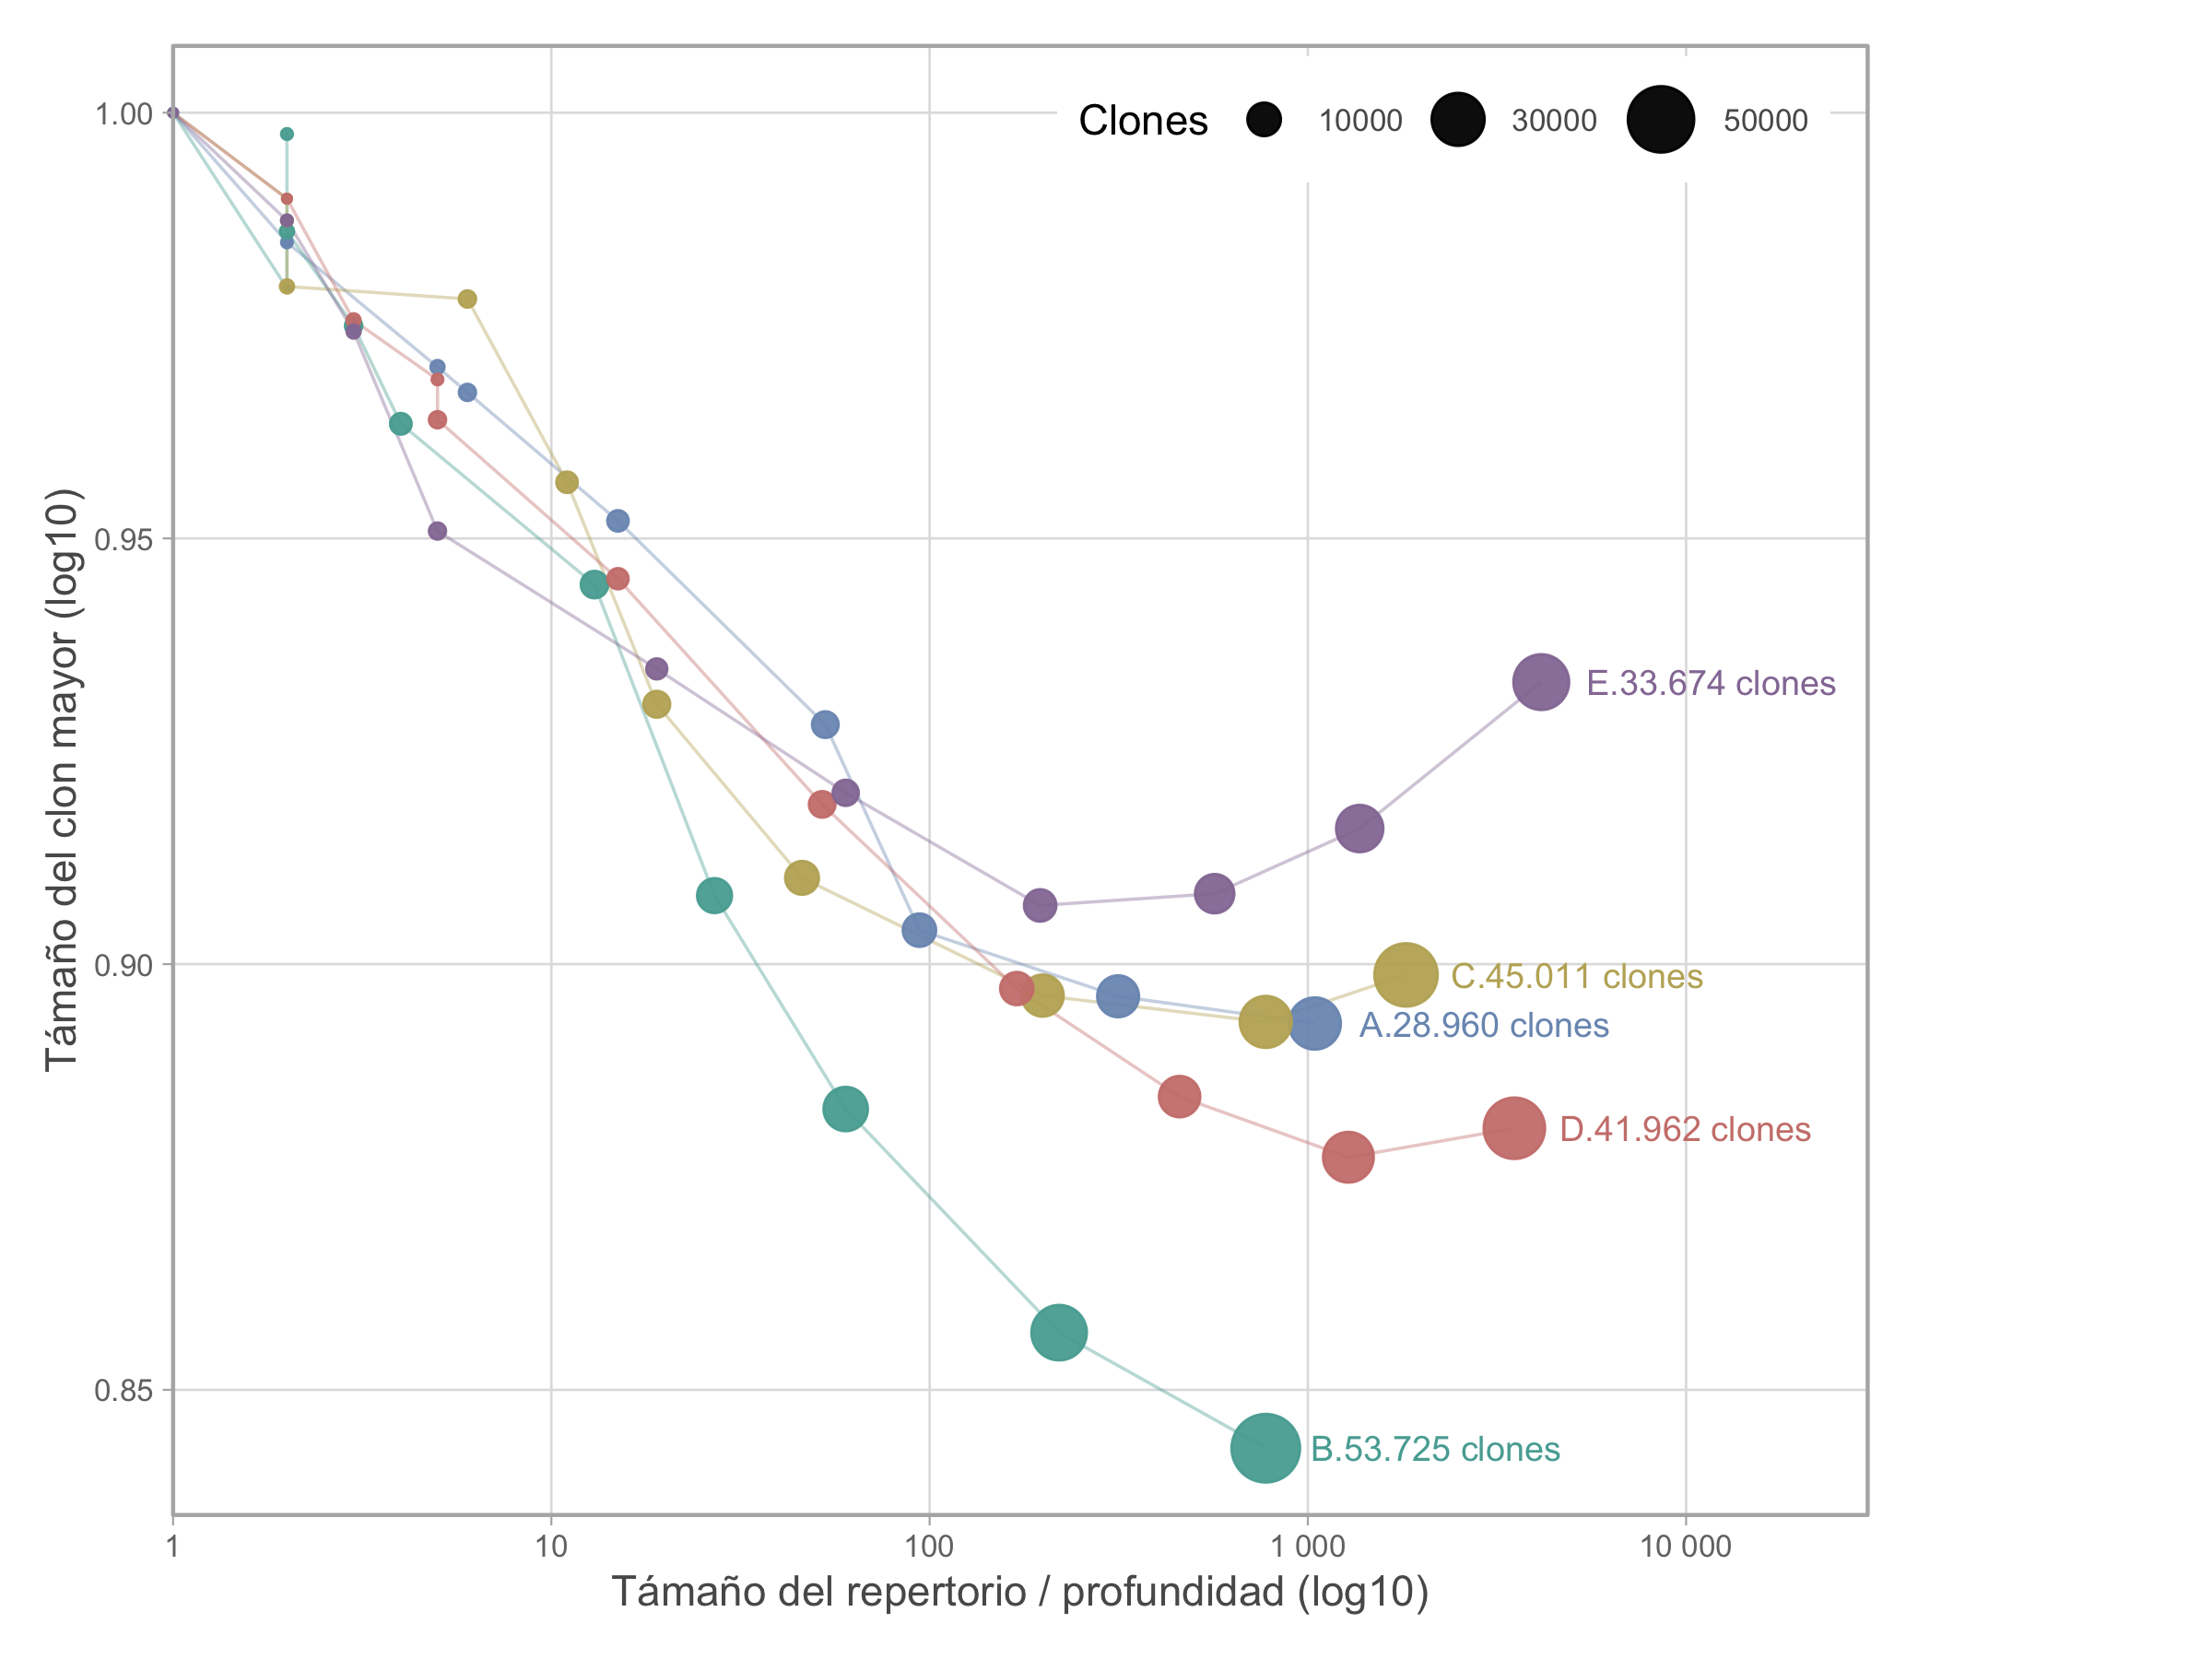

In [36]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 300)

colors <- c(A = "#7B98BE", B = "#58ABA2", C = "#BFAF66", D = "#CD817C", E = "#957BA4")

ggplot(d, aes(x = clon_mayor, y = proporcion_singletons, color = escenario)) +
  geom_line(data = ~ filter(.x, completo), linewidth = 0.4, alpha = 0.4) +
  geom_point(data = ~ filter(.x, completo), aes(size = n_clones), alpha = 0.95) +
  geom_text(
    data = fin,
    aes(label = etiqueta),
    hjust = 0,
    nudge_x = 0.12,
    size = 3.2,
  ) +
  scale_x_log10(
    breaks = c(1, 10, 100, 1000, 10000),
    labels = c("1", "10", "100", "1 000", "10 000"),
    limits = c(1, 10000),
    expand = expansion(mult = c(0, 0.12))
  ) +
  scale_size(
    range = c(0.5, 8),
    breaks = c(10000, 30000, 50000),
  ) +
  scale_color_manual(values = colors, guide = "none") +
  coord_cartesian(clip = "off") +
 labs(
  x = "T\u00E1ma\u00F1o del repertorio / profundidad (log10)",
  y = "T\u00E1ma\u00F1o del clon mayor (log10)",
  size = "Clones"
)+
  theme_light() +
  theme(
    plot.title = element_text(size = 9, colour = "grey35", hjust = 0, margin = margin(b = 14)),
    plot.margin = margin(12, 90, 12, 12),
    axis.title = element_text(colour = "grey35"),
    axis.text = element_text(size = 8, colour = "grey45"),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey88", linewidth = 0.3),
    legend.position = "inside",
    legend.position.inside = c(0.75, 0.95),
    legend.direction = "horizontal",
    legend.text = element_text(size = 8, colour = "grey35"),
  )

  


<theme> List of 144
 $ line                            : <ggplot2::element_line>
  ..@ colour       : chr "black"
  ..@ linewidth    : num 0.5
  ..@ linetype     : num 1
  ..@ lineend      : chr "butt"
  ..@ linejoin     : chr "round"
  ..@ arrow        : logi FALSE
  ..@ arrow.fill   : chr "black"
  ..@ inherit.blank: logi TRUE
 $ rect                            : <ggplot2::element_rect>
  ..@ fill         : chr "white"
  ..@ colour       : chr "black"
  ..@ linewidth    : num 0.5
  ..@ linetype     : num 1
  ..@ linejoin     : chr "round"
  ..@ inherit.blank: logi TRUE
 $ text                            : <ggplot2::element_text>
  ..@ family       : chr ""
  ..@ face         : chr "plain"
  ..@ italic       : chr NA
  ..@ fontweight   : num NA
  ..@ fontwidth    : num NA
  ..@ colour       : chr "black"
  ..@ size         : num 11
  ..@ hjust        : num 0.5
  ..@ vjust        : num 0.5
  ..@ angle        : num 0
  ..@ lineheight   : num 0.9
  ..@ margin       : <ggplot2::margin> nu

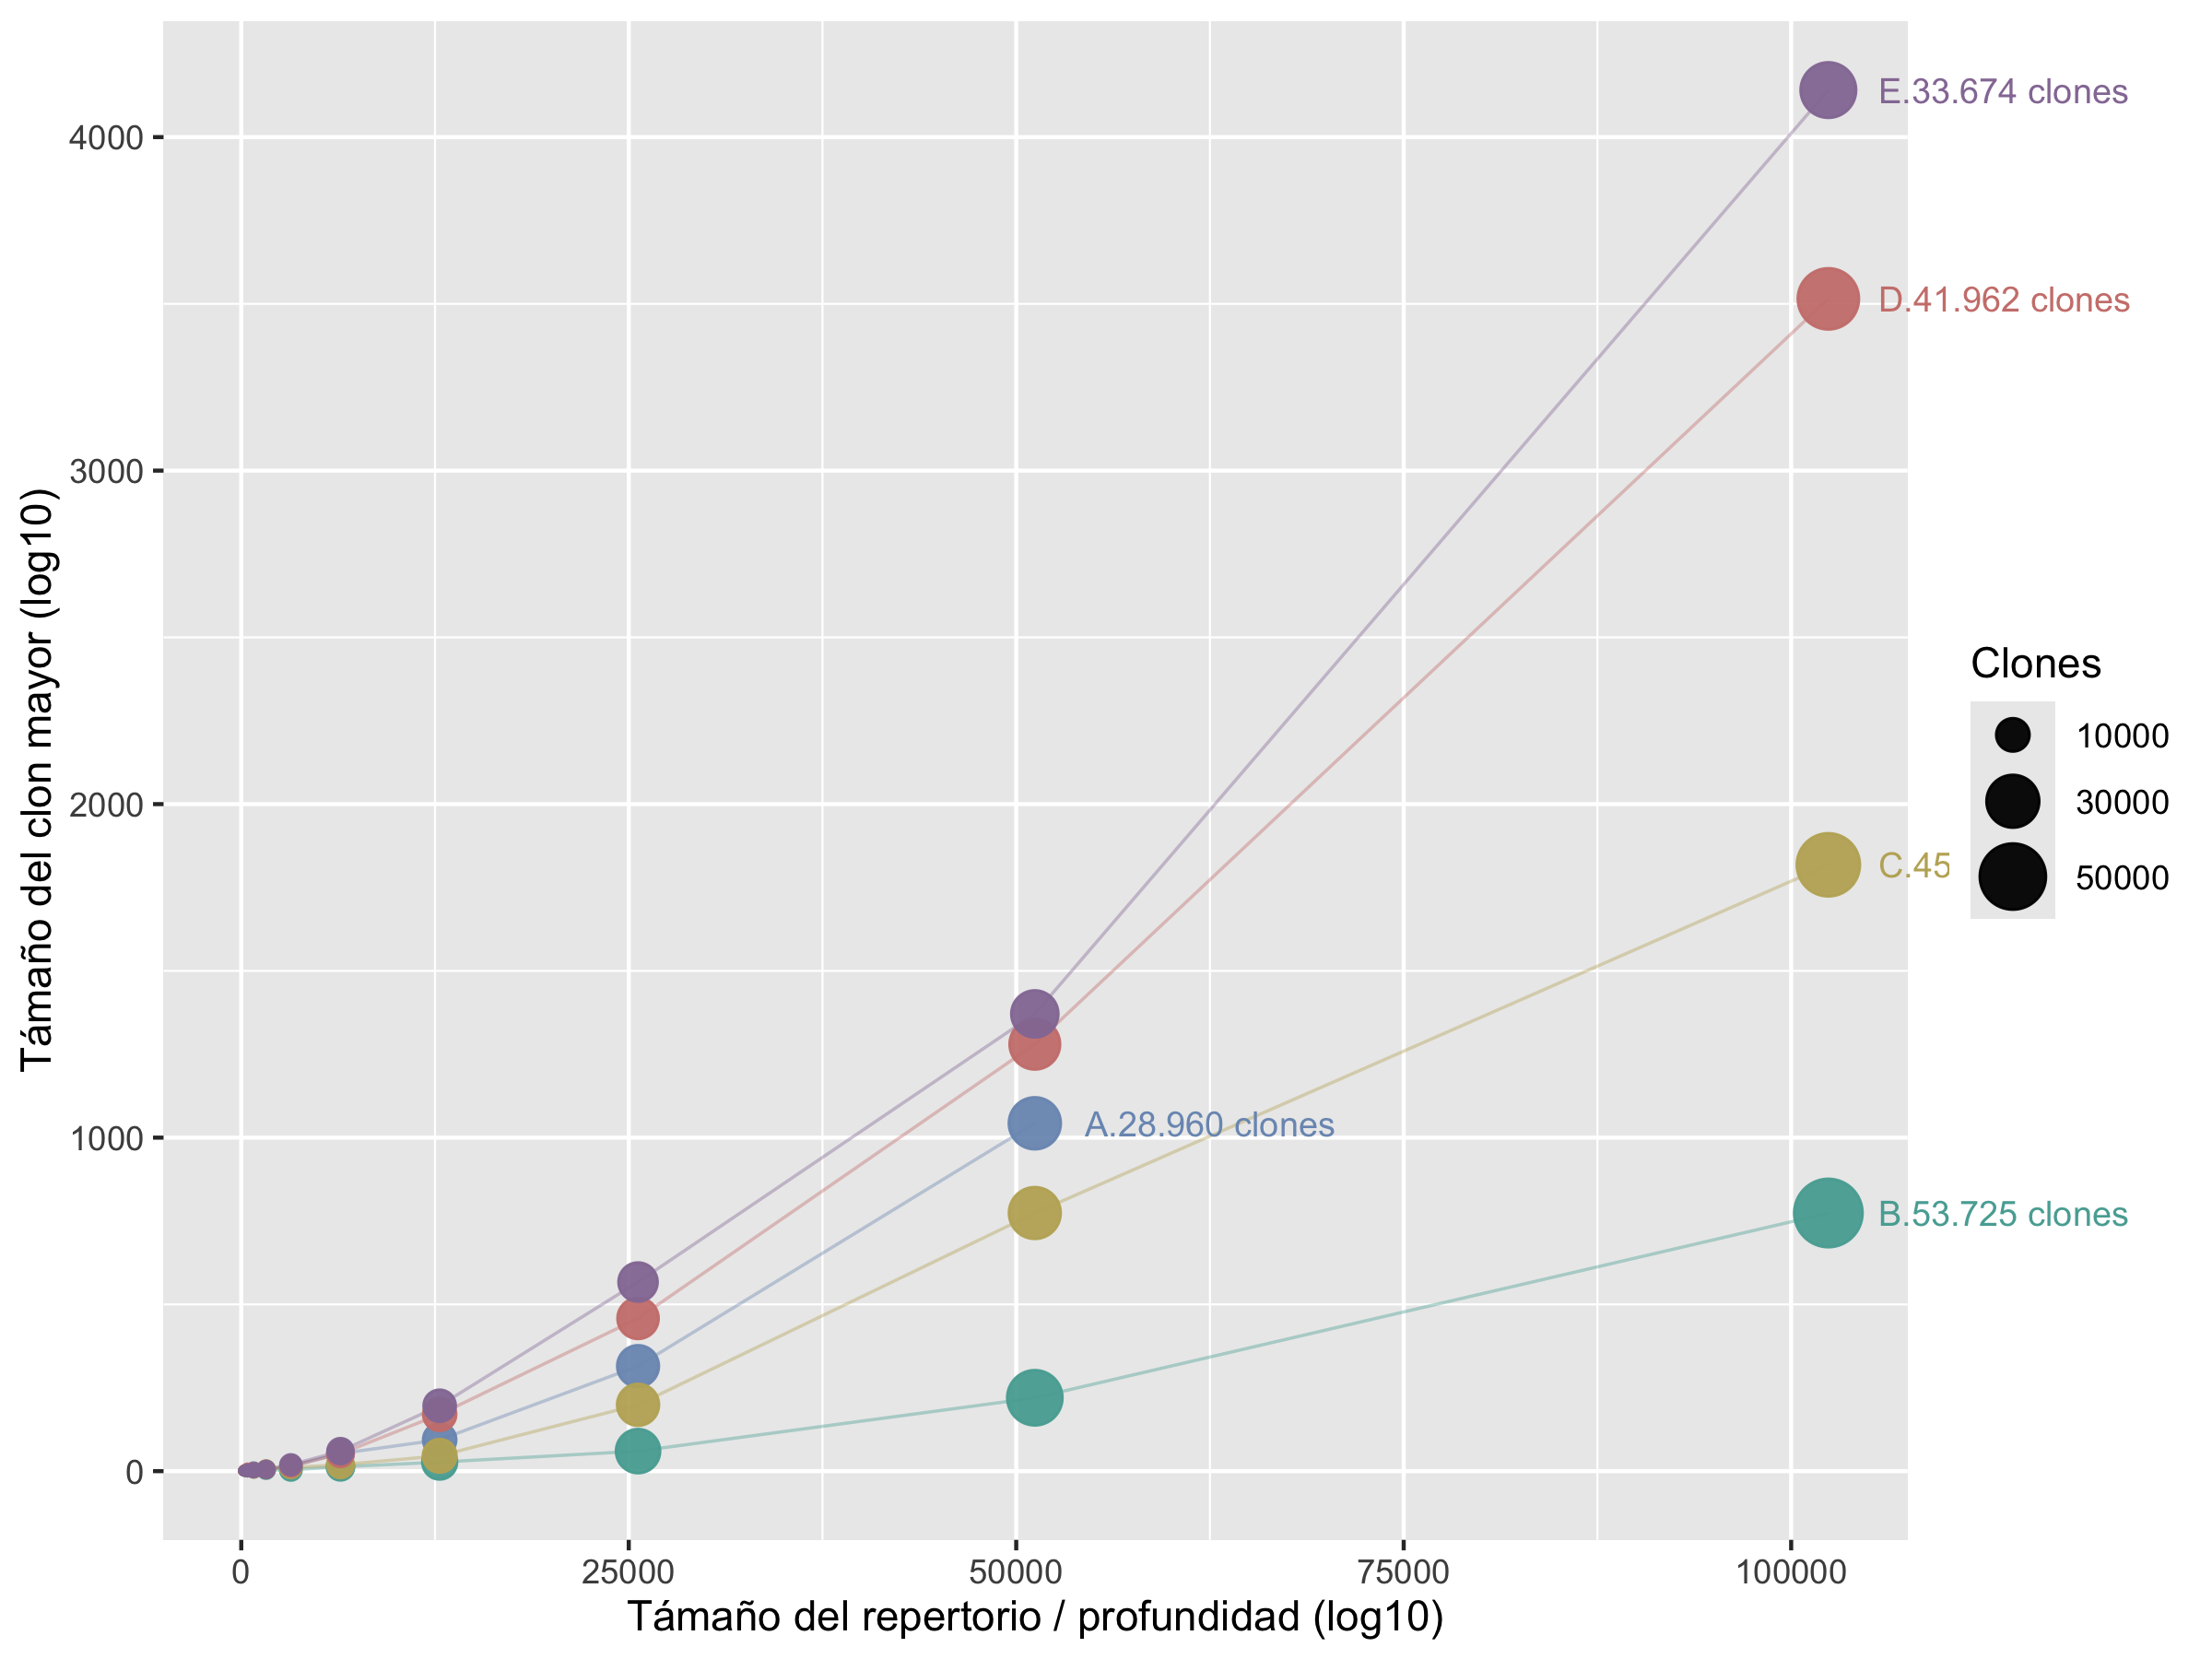

In [35]:
options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 300)

colors <- c(A = "#7B98BE", B = "#58ABA2", C = "#BFAF66", D = "#CD817C", E = "#957BA4")


ggplot(d, aes(x = profundidad, y = clon_mayor, color = escenario)) +
  geom_line(data = ~ filter(.x, completo), linewidth = 0.4, alpha = 0.4) +
  geom_point(data = ~ filter(.x, completo), aes(size = n_clones), alpha = 0.95) +
  geom_text(
     data = fin,
    aes(label = etiqueta),
    hjust = -0.2,
    nudge_x = 0.12,
    size = 3.2,
  ) +
  # scale_x_log10(
    # breaks = c(100, 1000, 10000, 100000),
    # labels = c("100", "1 000", "10 000", "100 000"),
    # limits = c(100, 102400),
    # expand = expansion(mult = c(0, 0.12))
  # ) +
  # scale_y_log10(
    # breaks = c(1, 10, 100, 1000, 10000),
    # labels = c("1", "10", "100", "1 000", "10 000")
  # ) +
  scale_size(
    range = c(0.5, 8),
    breaks = c(10000, 30000, 50000),
  ) +
  scale_color_manual(values = colors, guide = "none") +
  coord_cartesian(clip = "off") +
  labs(
  x = "T\u00E1ma\u00F1o del repertorio / profundidad (log10)",
  y = "T\u00E1ma\u00F1o del clon mayor (log10)",
  size = "Clones"
)
  theme_light() +
 theme(
    plot.title = element_text(size = 9, colour = "grey35", hjust = 0, margin = margin(b = 14)),
    plot.margin = margin(12, 90, 12, 12),
    axis.title = element_text(colour = "grey35"),
    axis.text = element_text(size = 8, colour = "grey45"),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey88", linewidth = 0.3),
    legend.position = "inside",
    legend.position.inside = c(0.75, 0.95),
    legend.direction = "horizontal",
    legend.text = element_text(size = 8, colour = "grey35"),
 )

<theme> List of 144
 $ line                            : <ggplot2::element_line>
  ..@ colour       : chr "black"
  ..@ linewidth    : num 0.5
  ..@ linetype     : num 1
  ..@ lineend      : chr "butt"
  ..@ linejoin     : chr "round"
  ..@ arrow        : logi FALSE
  ..@ arrow.fill   : chr "black"
  ..@ inherit.blank: logi TRUE
 $ rect                            : <ggplot2::element_rect>
  ..@ fill         : chr "white"
  ..@ colour       : chr "black"
  ..@ linewidth    : num 0.5
  ..@ linetype     : num 1
  ..@ linejoin     : chr "round"
  ..@ inherit.blank: logi TRUE
 $ text                            : <ggplot2::element_text>
  ..@ family       : chr ""
  ..@ face         : chr "plain"
  ..@ italic       : chr NA
  ..@ fontweight   : num NA
  ..@ fontwidth    : num NA
  ..@ colour       : chr "black"
  ..@ size         : num 11
  ..@ hjust        : num 0.5
  ..@ vjust        : num 0.5
  ..@ angle        : num 0
  ..@ lineheight   : num 0.9
  ..@ margin       : <ggplot2::margin> nu

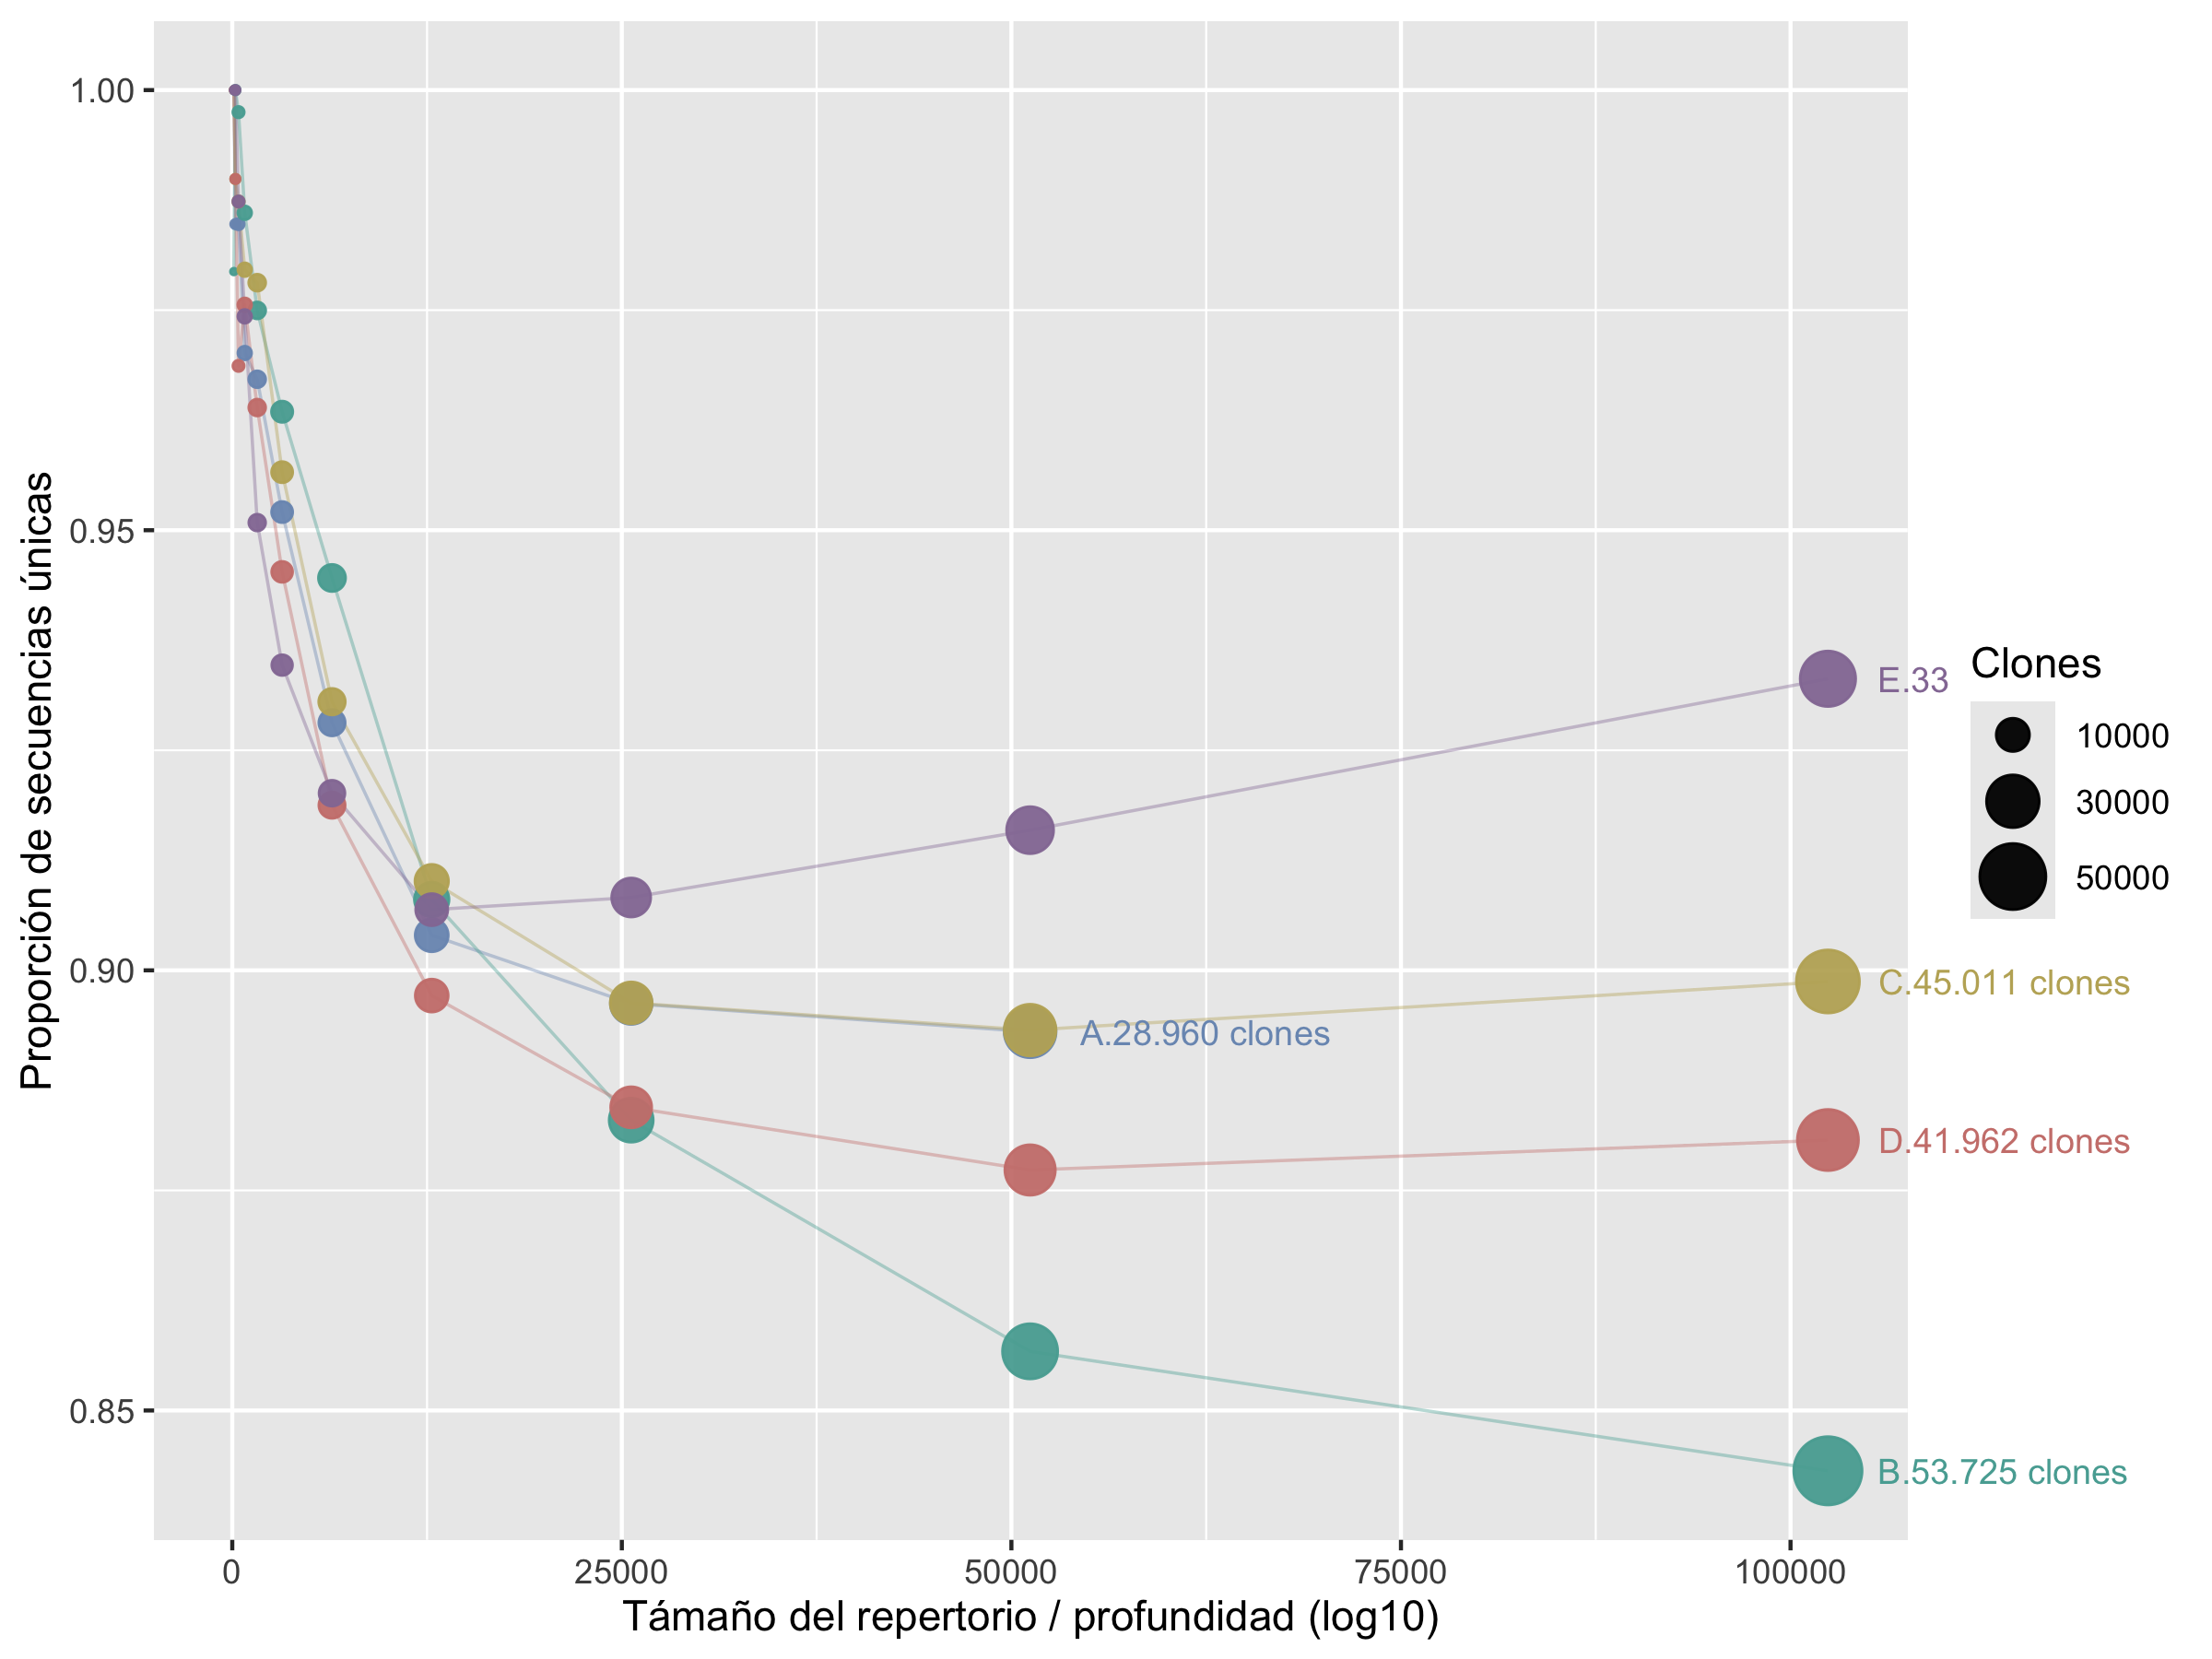

In [38]:

options(repr.plot.width = 8, repr.plot.height = 6, repr.plot.res = 300)

colors <- c(A = "#7B98BE", B = "#58ABA2", C = "#BFAF66", D = "#CD817C", E = "#957BA4")

ggplot(d, aes(x = profundidad, y = proporcion_singletons, color = escenario)) +
  geom_line(data = ~ filter(.x, completo), linewidth = 0.4, alpha = 0.4) +
  geom_point(data = ~ filter(.x, completo), aes(size = n_clones), alpha = 0.95) +
  geom_text(
    data = fin,
    aes(label = etiqueta),
    hjust = -0.2,
    nudge_x = 0.12,
    size = 3.2,
  ) +
  # scale_x_log10(
    # breaks = c(100, 1000, 10000, 100000),
    # labels = c("100", "1 000", "10 000", "100 000"),
    # limits = c(100, 102400),
    # expand = expansion(mult = c(0, 0.12))
  # ) +
  scale_size(
    range = c(0.5, 8),
    breaks = c(10000, 30000, 50000),
  ) +
  scale_color_manual(values = colors, guide = "none") +
  coord_cartesian(clip = "off") +
  labs(
  x = "T\u00E1ma\u00F1o del repertorio / profundidad (log10)",
  y = "Proporci\u00F3n de secuencias \u00FAnicas",
  size = "Clones"
)
  theme_light() +
  theme(
    plot.title = element_text(size = 9, colour = "grey35", hjust = 0, margin = margin(b = 14)),
    plot.margin = margin(12, 90, 12, 12),
    axis.title = element_text(colour = "grey35"),
    axis.text = element_text(size = 8, colour = "grey45"),
    panel.grid.minor = element_blank(),
    panel.grid.major = element_line(colour = "grey88", linewidth = 0.3),
    legend.position = "inside",
    legend.position.inside = c(0.75, 0.95),
    legend.direction = "horizontal",
    legend.text = element_text(size = 8, colour = "grey35"),
  )